In [1]:
import pandas as pd
import kagglehub

# MODEL_NAME = "Pulk17/Fake-News-Detection"
# FAKE_CLASS = 0
# TRUE_CLASS = 1

MODEL_NAME = "dhruvpal/fake-news-bert" 
FAKE_CLASS = 1
TRUE_CLASS = 0

def first_n_words(text, n=300):
    words = text.split()
    return ' '.join(words[:n])

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
real = pd.read_csv(f"{path}/True.csv")
fake = pd.read_csv(f"{path}/Fake.csv")

fake["label"] = FAKE_CLASS   # Fake
real["label"] = TRUE_CLASS   # Real

df_concat = pd.concat([fake, real], ignore_index=True)
df_concat["text"] = df_concat["title"] + " " + df_concat["text"]
df_concat["text"] = df_concat["text"].map(first_n_words)
df_concat = df_concat[["text", "label"]]

df = df_concat.sample(frac=1, random_state=42).reset_index(drop=True)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.


In [2]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [4]:
import numpy as np

def _to_list_of_str(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        return [texts]

    return ["" if t is None else str(t) for t in texts]

def tokenize(texts):
    texts = _to_list_of_str(texts)
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

def predict(texts):
    texts = _to_list_of_str(texts)
    with torch.no_grad():
        inputs = tokenize(texts)
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()

@torch.inference_mode()
def predict_torch(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
        max_length=256,
    )

    enc = {k: v.to(device) for k, v in enc.items()}

    out = model(**enc)

    logits = out.logits if hasattr(out, "logits") else out[0]
    probs = torch.softmax(logits, dim=-1)

    return probs.detach().cpu().numpy()

def predict_tokens(tokens):
    with torch.no_grad():
        outputs = model(**tokens)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    return probs

In [5]:
import torch
import numpy as np
from tqdm import tqdm

def batch_encodings(test_encodings, first, last):
    batch_input_ids = test_encodings['input_ids'][first:last]
    batch_attention_mask = test_encodings['attention_mask'][first:last]
    # batch_token_type_ids = test_encodings['token_type_ids'][first:last]

    return {
        'input_ids': batch_input_ids,
        'attention_mask': batch_attention_mask,
        # 'token_type_ids': batch_token_type_ids
    }

TEST_N_BATCHES = 40

test_encodings = tokenize(test_texts)
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}
batch_size = 128
test_labels = test_labels[:TEST_N_BATCHES * batch_size]

# Define a batch size for inference to prevent OutOfMemory errors
predictions = []

# Get the total number of test samples
num_samples = test_encodings['input_ids'].shape[0]

with torch.no_grad():
    # for i in tqdm(range(0, num_samples, batch_size)):
    for i in tqdm(range(0, batch_size * TEST_N_BATCHES, batch_size)):
        # Extract batch from test_encodings
        batch = batch_encodings(test_encodings, i, i + batch_size)

        # Perform inference on the batch
        outputs = model(**batch)
        batch_predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_predictions)

# Convert the list of predictions to a numpy array
predictions = np.array(predictions)

100%|██████████| 40/40 [00:07<00:00,  5.45it/s]


In [6]:
present_tokens = test_encodings['input_ids'] > 0
present_tokens = torch.sum(present_tokens, dim = -1, dtype = int)
# present_tokens = torch.tensor(sorted(present_tokens.tolist()))

print(torch.max(present_tokens))
print(torch.median(present_tokens))
print(torch.min(present_tokens))

tensor(256, device='cuda:0')
tensor(256, device='cuda:0')
tensor(14, device='cuda:0')


In [7]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}\n")
print(classification_report(test_labels, predictions, target_names=["Fake", "Real"]))

Test Accuracy: 0.9992

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2415
        Real       1.00      1.00      1.00      2705

    accuracy                           1.00      5120
   macro avg       1.00      1.00      1.00      5120
weighted avg       1.00      1.00      1.00      5120



In [8]:
import shap

masker = shap.maskers.Text(
    tokenizer=tokenizer,
    mask_token=tokenizer.mask_token,
)

explainer = shap.Explainer(
    predict_torch,
    masker,
    output_names=['fake', 'real'],
    algorithm='partition',
)

In [9]:
def top_words(shap_values, n=1, sample_idx=0, class_idx=0, top_k=10):
    dfs = []

    for sample_idx in range(n):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        df = pd.DataFrame({
            "token": tokens,
            "importance": values
        })

        df = df[df.token.str.strip() != ""]
        df["abs"] = df.importance.abs()

        dfs.append(df.sort_values("abs", ascending=False).head(top_k))

    return dfs

In [10]:
import matplotlib.pyplot as plt

def plot_top_words(dfs):
    for i in range(len(dfs)):
        plt.figure(figsize=(8, 4))
        plt.barh(
            dfs[i].token[::-1],
            dfs[i].importance[::-1]
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title("Most Important Words (SHAP)")
        plt.xlabel("Impact on prediction")
        plt.tight_layout()
        plt.show()

# plot_top_words(top_words(shap_values, 2))

In [ ]:
import numpy as np
import copy

N_TEXTS = 50
ROUNDS = 20          
MAX_STEPS = 50
TARGETED = True
TARGET_CLASS = TRUE_CLASS 
EPS = 1e-3

texts = None
if TARGET_CLASS == TRUE_CLASS:
    texts = df_concat.iloc[:int(2e4)].sample(frac=N_TEXTS/2e4, random_state=42).reset_index(drop=True)
    texts = texts["text"].dropna().tolist()
else:
    texts = df_concat.iloc[-int(2e4):].sample(frac=N_TEXTS/2e4, random_state=42).reset_index(drop=True)
    texts = texts["text"].dropna().tolist()

current_texts = copy.deepcopy(texts)
current_pred  = predict_torch(current_texts)
first_pred    = current_pred.copy()

num_chars_deleted = np.zeros((N_TEXTS, ROUNDS))
num_words_deleted = np.zeros((N_TEXTS, ROUNDS))
words_deleted = [set() for _ in range(N_TEXTS)]

def join_tokens(tokens):
    return "".join(tokens)

def current_target_class(i):
    return TARGET_CLASS if TARGETED else int(np.argmax(current_pred[i]))

def pick_ranking(shap_vals_i, class_idx, mode="pos"):
    v = shap_vals_i[:, class_idx]

    if mode == "abs":
        return np.argsort(-np.abs(v))
    else:
        return np.argsort(-v)

def compute_change(i, new_pred_i):
    if TARGETED:
        cls = TARGET_CLASS
        return new_pred_i[cls] - current_pred[i, cls]
    else:
        cls = int(np.argmax(current_pred[i]))
        return current_pred[i, cls] - new_pred_i[cls]

def check_flipped(new_pred_i):
    if TARGETED:
        cls = TARGET_CLASS
        return new_pred_i[cls] > new_pred_i[1-cls]

    else:
        return False

flipped = np.zeros(N_TEXTS, dtype=bool)

for round_num in range(ROUNDS):
    shap_values = explainer(current_texts)

    ranks = []
    toks_cache = []
    for i in range(N_TEXTS):
        original_class = 1 - TARGET_CLASS 
        ranks.append(pick_ranking(shap_values.values[i], original_class, mode="pos"))
        toks_cache.append(list(shap_values.data[i]))

    altered = np.zeros(N_TEXTS, dtype=bool)
    for step in range(MAX_STEPS):
        new_texts = current_texts.copy()

        for i in range(N_TEXTS):
            if flipped[i]:
                continue

            r = ranks[i]
            deleted_idx = int(r[step]) if step < len(r) else r[0]

            toks = toks_cache[i].copy()
            toks[deleted_idx] = ""
            new_texts[i] = join_tokens(toks)

        new_pred = predict_torch(new_texts)

        for i in range(N_TEXTS):
            if flipped[i]:
                continue

            flipped[i] = check_flipped(new_pred[i])
            if flipped[i]:
                print(f"Sample {i} flipped.")

            change = compute_change(i, new_pred[i])
            r = ranks[i]
            deleted_idx = int(r[step]) if step < len(r) else r[0]
            deleted_word = toks_cache[i][deleted_idx]

            if change > EPS:
                print(f"Deleting word {deleted_word} in sample {i} with attribution {shap_values.values[i][deleted_idx]} prediction change {change}")
                num_chars_deleted[i, round_num] += len(deleted_word)
                num_words_deleted[i, round_num] += 1
                words_deleted[i].add(deleted_word)

                toks_cache[i][deleted_idx] = ""
                current_texts[i] = new_texts[i]
                current_pred[i]  = new_pred[i]
                altered[i] = True

    print("Altering unaltered samples")
    for i in range(N_TEXTS):
        if not altered[i] and not flipped[i]:
            deleted_idx = ranks[i][0]
            deleted_word = toks_cache[i][deleted_idx]

            num_chars_deleted[i, round_num] += len(deleted_word)
            num_words_deleted[i, round_num] += 1
            # print(f"Deleting word {deleted_word} in sample {i} with attribution {shap_values.values[i][deleted_idx]}")

            toks = toks_cache[i].copy()
            toks[deleted_idx] = ""
            current_texts[i] = join_tokens(toks)

            toks_cache[i][deleted_idx] = ""
    
    current_pred = predict_torch(current_texts)

    flips = np.sum(np.argmax(current_pred, axis=1) != np.argmax(first_pred, axis=1))
    print(f"round={round_num:02d} flips={flips}/{N_TEXTS}")

PartitionExplainer explainer: 51it [00:38,  1.00s/it]                        


Deleting word ]  in sample 0 with attribution [-0.02409852  0.02409852] prediction change 0.04802479222416878
Sample 5 flipped.
Deleting word ]  in sample 5 with attribution [-0.03691585  0.03691585] prediction change 0.9969678521156311
Sample 9 flipped.
Deleting word s  in sample 9 with attribution [-0.12467139  0.12467139] prediction change 0.9993318319320679
Deleting word Vo in sample 0 with attribution [-0.00616662  0.00616662] prediction change 0.04000408947467804
Sample 0 flipped.
Deleting word Video in sample 0 with attribution [-0.0019129  0.0019129] prediction change 0.9119502305984497
Altering unaltered samples
round=00 flips=3/50


PartitionExplainer explainer: 51it [00:40,  1.01s/it]                        


Sample 14 flipped.
Deleting word Video in sample 14 with attribution [-0.49921095  0.49921092] prediction change 0.998238742351532
Sample 16 flipped.
Deleting word ] in sample 16 with attribution [-0.4373448   0.43734478] prediction change 0.9999304413795471
Altering unaltered samples
round=01 flips=5/50


PartitionExplainer explainer: 51it [00:41,  1.03s/it]                        


...

Deleting word PA in sample 8 with attribution [ 5.31429389e-05 -5.31710684e-05] prediction change 0.0011282125487923622
Altering unaltered samples
round=12 flips=15/50


PartitionExplainer explainer: 51it [00:45,  1.13s/it]                        


Altering unaltered samples
round=13 flips=15/50


PartitionExplainer explainer: 51it [00:45,  1.14s/it]                        


Sample 6 flipped.
Deleting word ]  in sample 6 with attribution [-0.01569252  0.01569252] prediction change 0.9999307990074158
Deleting word Y  in sample 8 with attribution [-0.00212217  0.00212218] prediction change 0.005838125478476286
Deleting word BARACK  in sample 28 with attribution [-0.05043498  0.05043498] prediction change 0.00778439175337553
Deleting word National  in sample 8 with attribution [-0.0003203   0.00032028] prediction change 0.011462907306849957
Deleting word t  in sample 31 with attribution [-0.0272058  0.0272058] prediction change 0.006135731004178524
Deleting word PLAY  in sample 8 with attribution [ 0.00025408 -0.00025406] prediction change 0.0015356950461864471
Deleting word TO  in sample 8 with attribution [ 0.00038518 -0.00038518] prediction change 0.002641497179865837
Deleting word 46  in sample 31 with attribution [-0.01370368  0.01370368] prediction change 0.1383466124534607
Sample 31 flipped.
Deleting word the  in sample 31 with attribution [-0.01370368

In [14]:
print(flipped)

[ True False  True False  True  True False False False  True False False
 False  True  True False  True False False False  True False False False
 False  True False False False False False False False False  True  True
 False False False False  True False False False  True False False False
  True False]


In [15]:
print(words_deleted)

[{'Vo', '] ', 'Video'}, set(), {'s '}, set(), {'! '}, {'] '}, set(), set(), {'By ', 'WI', 'PA', 'EL', 'Our ', 'KI', 'LEAH'}, {'s '}, set(), set(), set(), {'WOW', '! '}, {'Video'}, set(), {']'}, set(), set(), set(), {'is ', '/', 'hilarious', 'the ', 'single '}, set(), set(), set(), set(), {'VIDEO', '] '}, set(), set(), {'God', 'VINTAGE '}, set(), set(), set(), set(), set(), {'? ', 'Compare ', 'billion ', 'Via', '…'}, {'/'}, set(), set(), set(), set(), {'. ', ': '}, set(), set(), set(), {'Washington', 'Via'}, set(), set(), set(), {'] '}, set()]


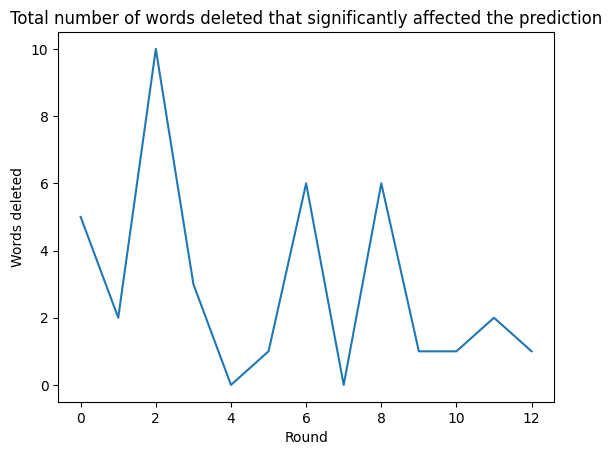

In [18]:
words_deleted_per_round = num_words_deleted.sum(axis=0)

import matplotlib.pyplot as plt
import numpy as np

rounds = np.arange(len(words_deleted_per_round))

plt.figure()
plt.plot(rounds, words_deleted_per_round)
plt.xlabel("Round")
plt.ylabel("Words deleted")
plt.title("Total number of words deleted that significantly affected the prediction")
plt.show()
